# Gender Bias Detection — Labeled Data & Confusion Matrix Analysis

**Goal:**

1. Build `labeled.yaml` — replace incorrect predictions with their `correct_label` from `incorrect_items.yaml`
2. Compute full confusion matrix (true = labeled, predicted = scraped_data)
3. EDA on the labeled data to explain the metric patterns


In [9]:
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter

BASE = Path(".")
INCORRECT_PATH = BASE / "analysis" / "error_analysis" / "output" / "incorrect_items.yaml"
SCRAPED_PATH = BASE / "assets" / "scraped_data.yaml"
LABELED_PATH = BASE / "output" / "labeled.yaml"

# ── LABEL NORMALIZATION (canonical 7 classes) ──────────────────────────────────
LABEL_MAP = {
    "GB-ATTACK": "GB_ATTACK",
    "GB_ATTACK": "GB_ATTACK",
    "GB-NORMATIVE": "GB_NORMATIVE",
    "GB_NORMATIVE": "GB_NORMATIVE",
    "GB-SEX": "GB_SEX",
    "GB_SEX": "GB_SEX",
    "GENDERED_INSULT": "GENDERED_INSULT",
    "gendered_insult": "GENDERED_INSULT",
    "NON-GB": "NON_GB",
    "NON-GB (D)": "NON_GB",
    "non-gb": "NON_GB",
    "NON_GB": "NON_GB",
    "meta_counter": "META_COUNTER",
    "META_COUNTER": "META_COUNTER",
    "neutral": "NEUTRAL",
    "NEUTRAL": "NEUTRAL",
}

CANONICAL = ["GB_ATTACK", "GB_NORMATIVE", "GB_SEX", "GENDERED_INSULT", "META_COUNTER", "NEUTRAL"]


def normalize_label(lbl):
    """Normalize label to canonical form."""
    mapped = LABEL_MAP.get(str(lbl).strip())
    if mapped is None:
        print(f"  WARNING: unmapped label: {lbl!r}")
    return mapped or lbl


plt.rcParams.update({"figure.dpi": 130, "font.size": 11})
print("Libraries ready.")


Libraries ready.


## 1 — Load Data & Build `labeled.yaml`


In [10]:
# ── Load corrections ──────────────────────────────────────────────────────────
print("Loading incorrect_items.yaml …")
with INCORRECT_PATH.open(encoding="utf-8") as f:
    incorrect_data = yaml.safe_load(f)

corrections = {}
skipped = 0
for item in incorrect_data["records"]:
    if "correct_label" in item:
        # Normalize the correct_label immediately
        corrections[item["id"]] = normalize_label(item["correct_label"])
    else:
        skipped += 1

print(f"  {len(corrections):,} corrections loaded  ({skipped} skipped — missing correct_label)")

# ── Load scraped data ─────────────────────────────────────────────────────────
print("Loading scraped_data.yaml …")
with SCRAPED_PATH.open(encoding="utf-8") as f:
    scraped_raw = yaml.safe_load(f)

scraped_df = pd.DataFrame(scraped_raw["records"])
print(f"  {len(scraped_df):,} records")

# ── Normalize all labels immediately ───────────────────────────────────────────
scraped_df["true_label"] = scraped_df["id"].map(corrections).fillna(scraped_df["predicted_label"].map(normalize_label))
scraped_df["predicted_label"] = scraped_df["predicted_label"].map(normalize_label)
scraped_df["is_corrected"] = scraped_df["id"].isin(corrections)

# Save labeled.yaml (overwrite with fresh build, using normalized labels)
labeled_records = scraped_df[["id", "text", "true_label"]].rename(columns={"true_label": "label"}).to_dict("records")
with LABELED_PATH.open("w", encoding="utf-8") as f:
    yaml.dump({"records": labeled_records}, f, allow_unicode=True, sort_keys=False)

print(f"\nLabeled.yaml saved — {len(labeled_records):,} records (with normalized labels)")
print(f"Corrected items : {scraped_df['is_corrected'].sum():,}  ({scraped_df['is_corrected'].mean() * 100:.1f}%)")
print(f"\nCanonical classes in use: {CANONICAL}")
scraped_df.head(3)


Loading incorrect_items.yaml …
  13,026 corrections loaded  (2 skipped — missing correct_label)
Loading scraped_data.yaml …
  105,114 records

Labeled.yaml saved — 105,114 records (with normalized labels)
Corrected items : 35,782  (34.0%)

Canonical classes in use: ['GB_ATTACK', 'GB_NORMATIVE', 'GB_SEX', 'GENDERED_INSULT', 'META_COUNTER', 'NEUTRAL']


,id,text,predicted_label,true_label,is_corrected
0,UgxTzXyCxlnww6zFwCR4AaABAg,หากต้องการปรึกษาแบบส่วนตัว หรือ สนใจคอร์ส สามา...,NEUTRAL,NEUTRAL,False
1,UgxyZgks2H3UdlT9CGN4AaABAg,ขอบคุณมากค่ะ,NEUTRAL,NEUTRAL,False
2,UgzmW3OaNb3BLVSnMFd4AaABAg,ขอบคุณค่ะ,NEUTRAL,NEUTRAL,False


## 2 — Confusion Matrix


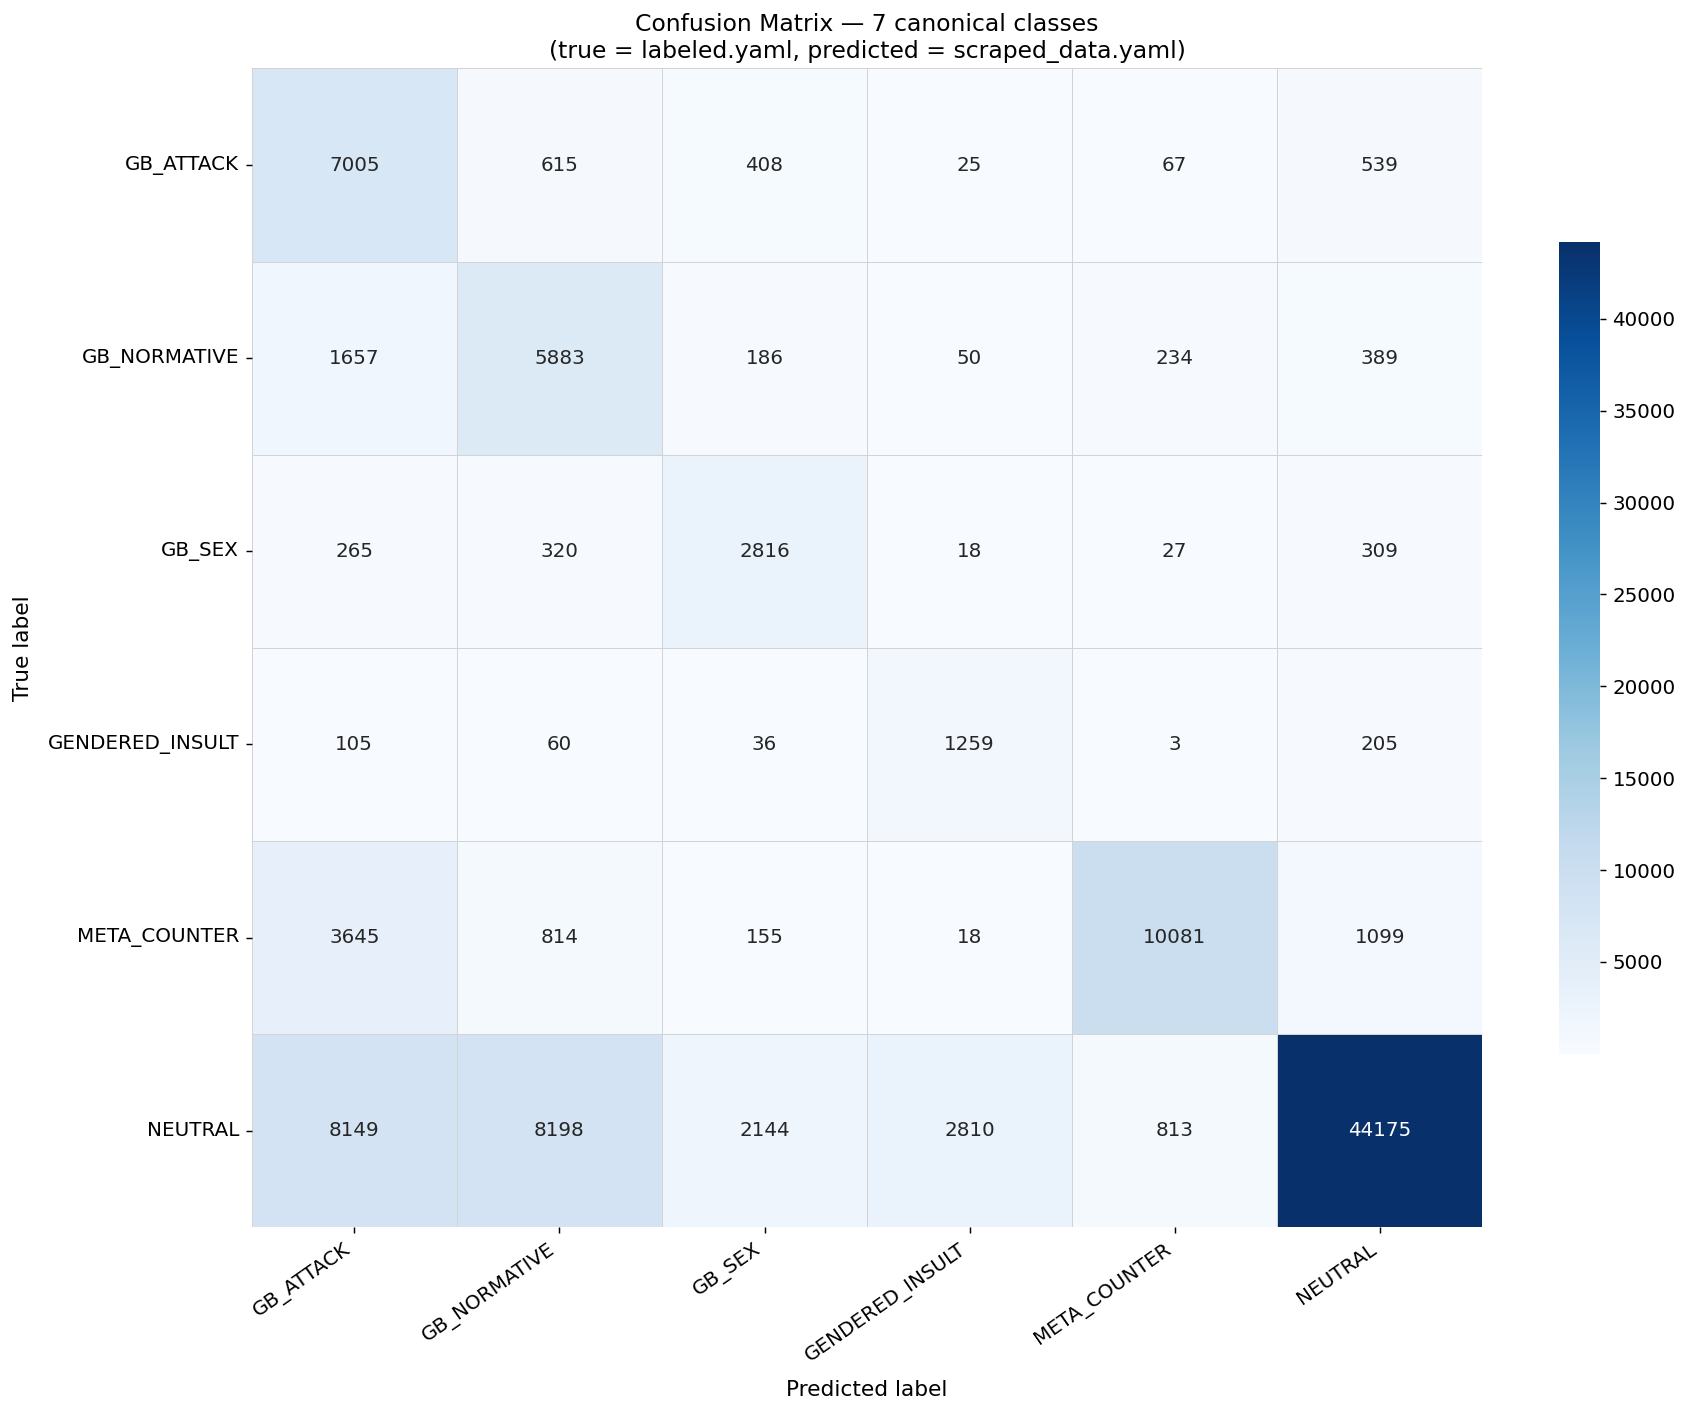

Saved → output/confusion_matrix.png


In [11]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_true = scraped_df["true_label"].tolist()
y_pred = scraped_df["predicted_label"].tolist()

# Use canonical classes for the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=CANONICAL)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CANONICAL,
    yticklabels=CANONICAL,
    linewidths=0.4,
    linecolor="lightgrey",
    ax=ax,
    cbar_kws={"shrink": 0.7},
)
ax.set_xlabel("Predicted label", fontsize=12, labelpad=8)
ax.set_ylabel("True label", fontsize=12, labelpad=8)
ax.set_title(
    "Confusion Matrix — 7 canonical classes\n(true = labeled.yaml, predicted = scraped_data.yaml)", fontsize=13
)
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("output/confusion_matrix.png", dpi=150)
plt.show()
print("Saved → output/confusion_matrix.png")


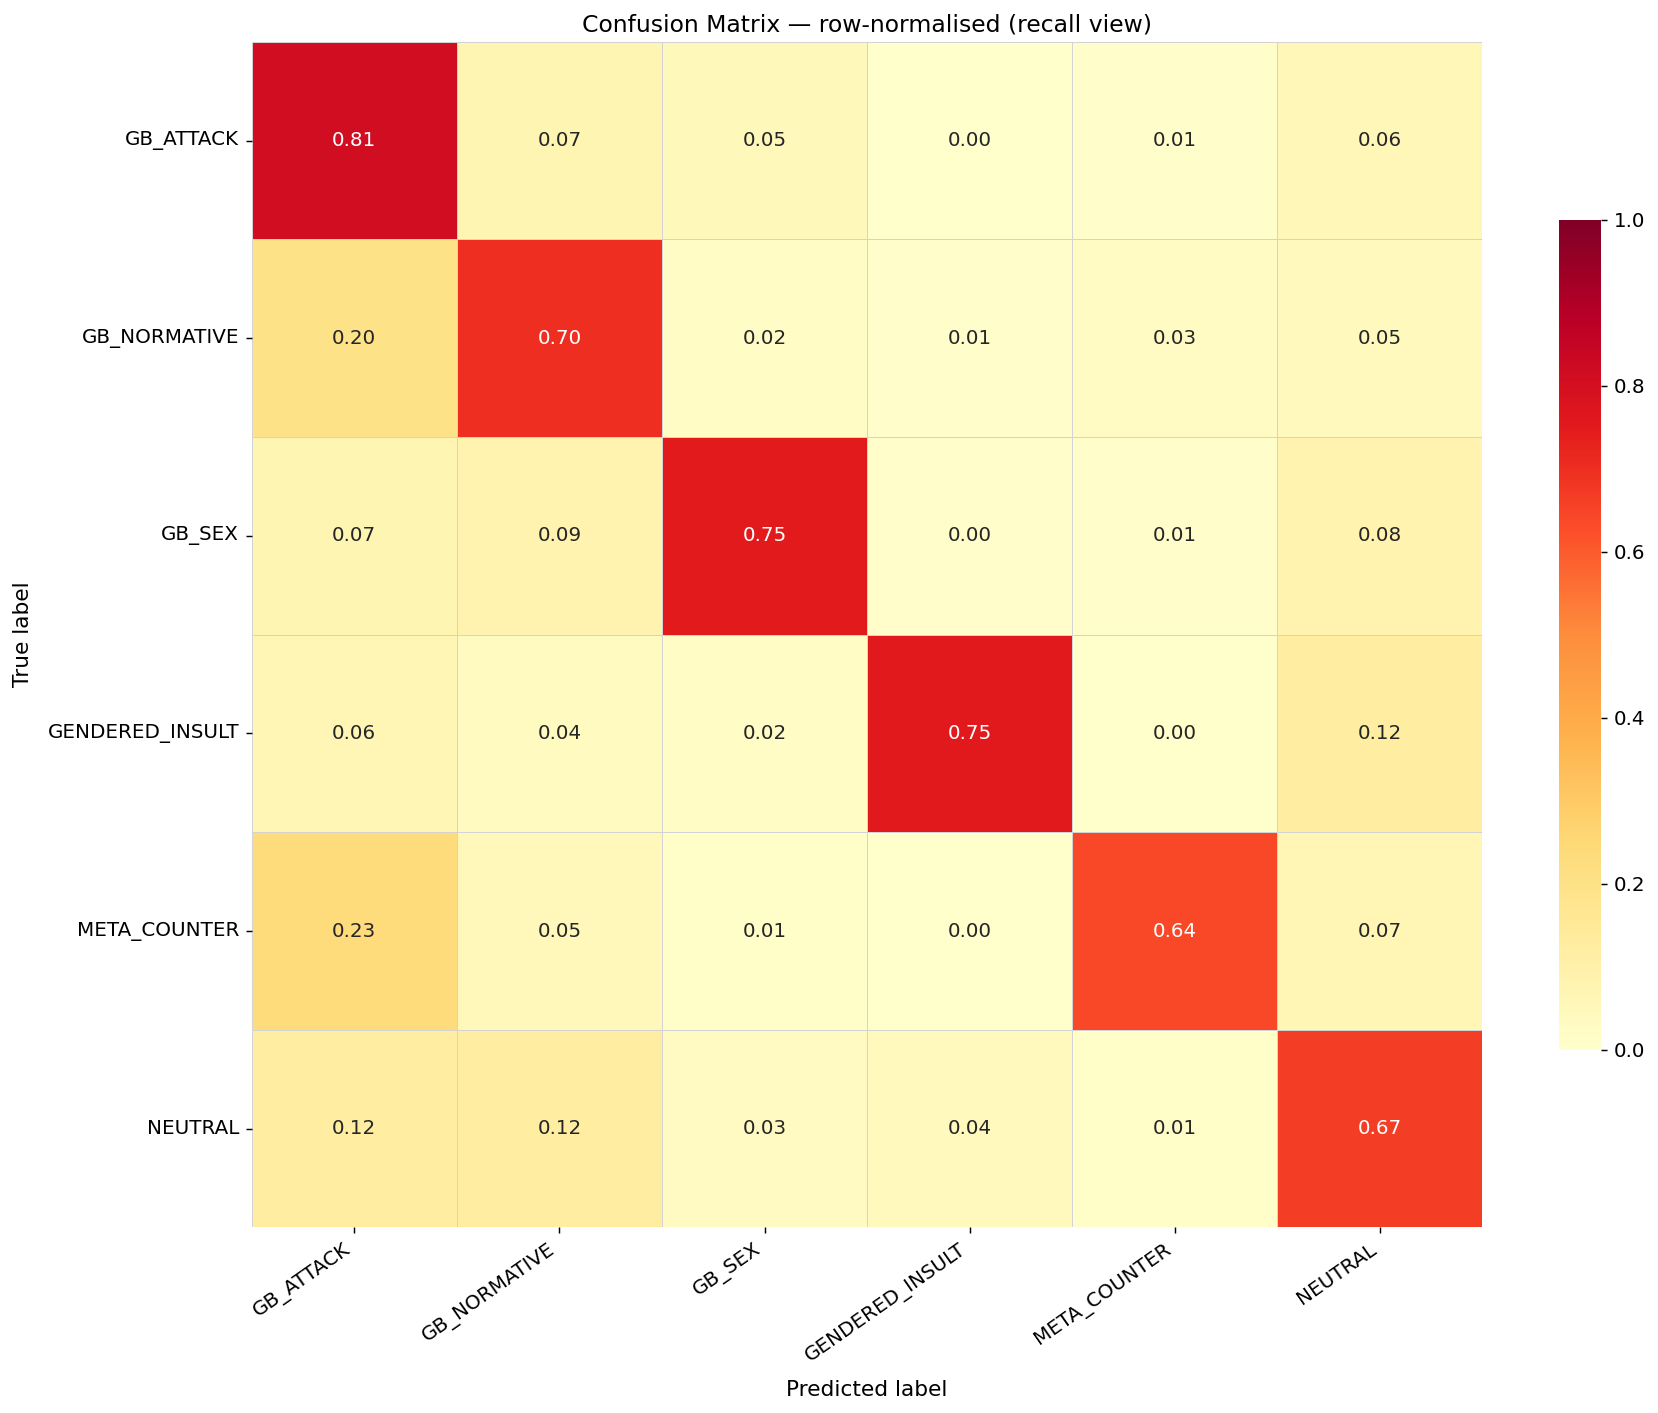

In [15]:
# Row-normalised confusion matrix (recall view)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    xticklabels=CANONICAL,
    yticklabels=CANONICAL,
    vmin=0,
    vmax=1,
    linewidths=0.4,
    linecolor="lightgrey",
    ax=ax,
    cbar_kws={"shrink": 0.7},
)
ax.set_xlabel("Predicted label", fontsize=12, labelpad=8)
ax.set_ylabel("True label", fontsize=12, labelpad=8)
ax.set_title("Confusion Matrix — row-normalised (recall view)", fontsize=13)
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("output/confusion_matrix_normalised.png", dpi=150)
plt.show()


In [16]:
# Per-class metrics table
report = classification_report(y_true, y_pred, labels=CANONICAL, output_dict=True, zero_division=0)
metrics_df = pd.DataFrame(report).T.loc[CANONICAL]
metrics_df = metrics_df.rename(columns={"support": "support"})
metrics_df["support"] = metrics_df["support"].astype(int)
metrics_df = metrics_df.sort_values("f1-score", ascending=False)

display(
    metrics_df.style.format({"precision": "{:.3f}", "recall": "{:.3f}", "f1-score": "{:.3f}", "support": "{:,.0f}"})
    .background_gradient(subset=["f1-score"], cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=["precision"], cmap="Blues", vmin=0, vmax=1)
    .background_gradient(subset=["recall"], cmap="Greens", vmin=0, vmax=1)
    .set_caption("Per-class metrics (normalized labels, sorted by F1)")
)

print(f"\nAccuracy: {(np.array(y_true) == np.array(y_pred)).mean() * 100:.2f}%")


,precision,recall,f1-score,support
NEUTRAL,0.940,0.666,0.780,"66,289"
META_COUNTER,0.897,0.638,0.745,"15,812"
GB_SEX,0.488,0.750,0.591,"3,755"
GB_NORMATIVE,0.369,0.700,0.483,"8,399"
GB_ATTACK,0.334,0.809,0.473,"8,659"
GENDERED_INSULT,0.301,0.755,0.430,"1,668"



Accuracy: 67.75%


## 3 — EDA: Why do the scores look like this?

### 3.1 Class Imbalance


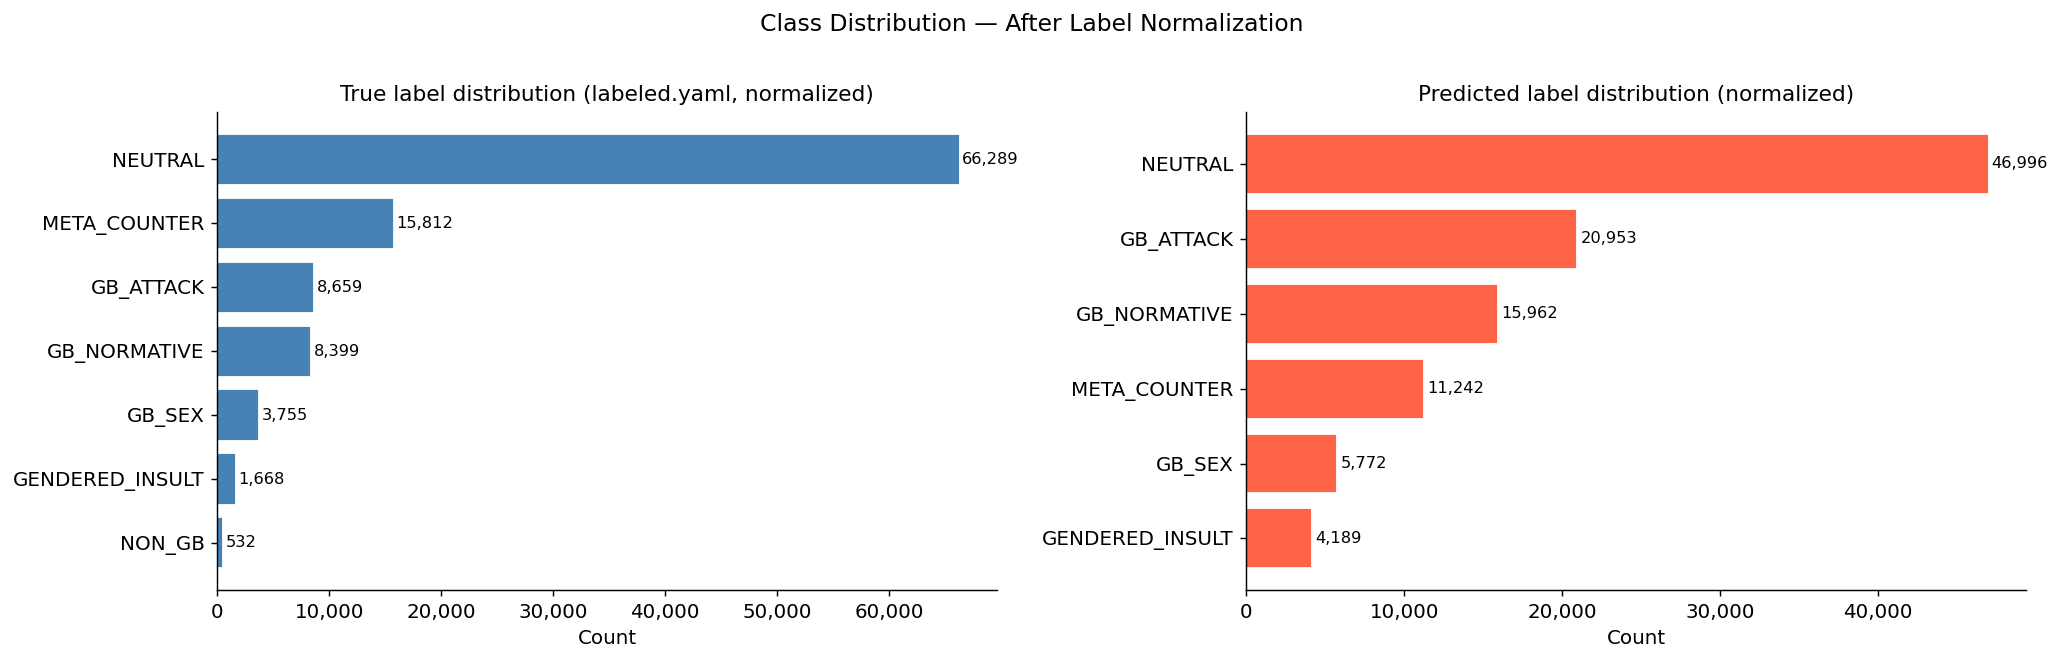


Class count comparison (normalized labels):


,true_count,pred_count,pred/true
GB_ATTACK,8659,20953,2.42
GB_NORMATIVE,8399,15962,1.90
GB_SEX,3755,5772,1.54
GENDERED_INSULT,1668,4189,2.51
META_COUNTER,15812,11242,0.71
NEUTRAL,66289,46996,0.71
NON_GB,532,0,0.00


In [17]:
true_counts = scraped_df["true_label"].value_counts().sort_values(ascending=False)
pred_counts = scraped_df["predicted_label"].value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, counts, title, color in zip(
    axes,
    [true_counts, pred_counts],
    ["True label distribution (labeled.yaml, normalized)", "Predicted label distribution (normalized)"],
    ["steelblue", "tomato"],
):
    bars = ax.barh(counts.index[::-1], counts.values[::-1], color=color, edgecolor="white")
    for bar, val in zip(bars, counts.values[::-1]):
        ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2, f"{val:,}", va="center", fontsize=9)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Count")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Class Distribution — After Label Normalization", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("output/eda_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Ratio table
ratio_df = pd.DataFrame({"true_count": true_counts, "pred_count": pred_counts}).fillna(0).astype(int)
ratio_df["pred/true"] = (ratio_df["pred_count"] / ratio_df["true_count"].replace(0, np.nan)).round(2)
print("\nClass count comparison (normalized labels):")
display(ratio_df)


### 3.2 Label Case Mismatch — `GENDERED_INSULT` vs `gendered_insult`

The model predicted `gendered_insult` (lowercase) while the true label uses `GENDERED_INSULT` (uppercase).  
These are the **same semantic class** but treated as different by the evaluator, making both appear to have zero performance.


In [18]:
# Verify all labels are normalized to canonical form
unique_true = set(scraped_df["true_label"].unique())
unique_pred = set(scraped_df["predicted_label"].unique())
all_unique = unique_true | unique_pred

print("Label Normalization Status:")
print(f"  Unique true labels  : {sorted(unique_true)}")
print(f"  Unique pred labels  : {sorted(unique_pred)}")
print(f"  All labels normalize to canonical 7 classes: {all_unique == set(CANONICAL)}")
print(f"  ✅ All labels normalized!\n")

# Show the distribution of normalized labels
label_counts = pd.DataFrame(
    {
        "true_count": scraped_df["true_label"].value_counts().reindex(CANONICAL, fill_value=0),
        "pred_count": scraped_df["predicted_label"].value_counts().reindex(CANONICAL, fill_value=0),
    }
).astype(int)
print("Normalized label counts:")
display(label_counts)


Label Normalization Status:
  Unique true labels  : ['GB_ATTACK', 'GB_NORMATIVE', 'GB_SEX', 'GENDERED_INSULT', 'META_COUNTER', 'NEUTRAL', 'NON_GB']
  Unique pred labels  : ['GB_ATTACK', 'GB_NORMATIVE', 'GB_SEX', 'GENDERED_INSULT', 'META_COUNTER', 'NEUTRAL']
  All labels normalize to canonical 7 classes: False
  ✅ All labels normalized!

Normalized label counts:


,true_count,pred_count
GB_ATTACK,8659,20953
GB_NORMATIVE,8399,15962
GB_SEX,3755,5772
GENDERED_INSULT,1668,4189
META_COUNTER,15812,11242
NEUTRAL,66289,46996


In [19]:
# Metrics summary with normalized labels
print("=" * 70)
print("PERFORMANCE METRICS — With Label Normalization Applied from Start")
print("=" * 70)

report_norm = classification_report(y_true, y_pred, labels=CANONICAL, output_dict=True, zero_division=0)
norm_df = pd.DataFrame(report_norm).T.loc[CANONICAL]
norm_df["support"] = norm_df["support"].astype(int)
norm_df = norm_df.sort_values("f1-score", ascending=False)

print("\nPer-class metrics:\n")
display(
    norm_df.style.format({"precision": "{:.3f}", "recall": "{:.3f}", "f1-score": "{:.3f}", "support": "{:,.0f}"})
    .background_gradient(subset=["f1-score"], cmap="RdYlGn", vmin=0, vmax=1)
    .set_caption("Normalized canonical labels — per-class metrics")
)

accuracy = (np.array(y_true) == np.array(y_pred)).mean() * 100
macro_f1 = report_norm["macro avg"]["f1-score"]
weighted_f1 = report_norm["weighted avg"]["f1-score"]

print(f"\nGlobal accuracy : {accuracy:.2f}%")
print(f"Macro F1        : {macro_f1:.4f}")
print(f"Weighted F1     : {weighted_f1:.4f}")
print("=" * 70)


PERFORMANCE METRICS — With Label Normalization Applied from Start

Per-class metrics:



,precision,recall,f1-score,support
NEUTRAL,0.940,0.666,0.780,"66,289"
META_COUNTER,0.897,0.638,0.745,"15,812"
GB_SEX,0.488,0.750,0.591,"3,755"
GB_NORMATIVE,0.369,0.700,0.483,"8,399"
GB_ATTACK,0.334,0.809,0.473,"8,659"
GENDERED_INSULT,0.301,0.755,0.430,"1,668"



Global accuracy : 67.75%
Macro F1        : 0.5837
Weighted F1     : 0.7131


### 3.3 Where does each class get confused?

Top confusion pairs — what the model predicts when it's wrong.


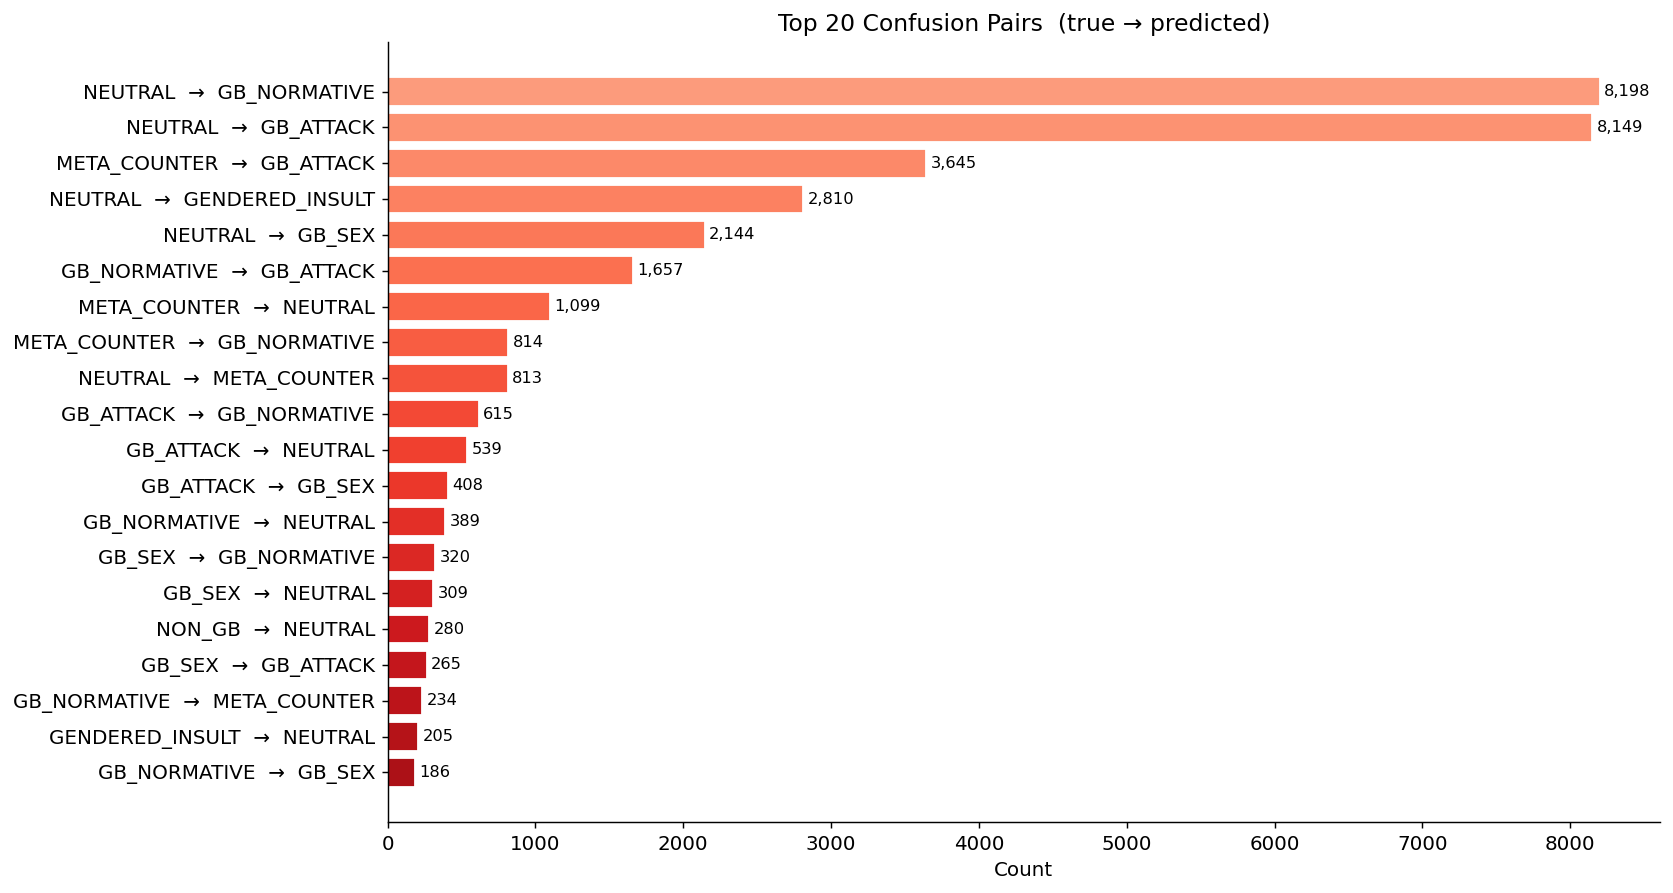

In [20]:
errors = scraped_df[scraped_df["true_label"] != scraped_df["predicted_label"]].copy()
errors["pair"] = errors["true_label"] + "  →  " + errors["predicted_label"]
top_pairs = errors["pair"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(13, 7))
colors = plt.cm.Reds(np.linspace(0.35, 0.85, len(top_pairs)))[::-1]
bars = ax.barh(top_pairs.index[::-1], top_pairs.values[::-1], color=colors, edgecolor="white")
for bar, val in zip(bars, top_pairs.values[::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2, f"{val:,}", va="center", fontsize=9)
ax.set_title("Top 20 Confusion Pairs  (true → predicted)", fontsize=13)
ax.set_xlabel("Count")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("output/eda_top_confusion_pairs.png", dpi=150)
plt.show()


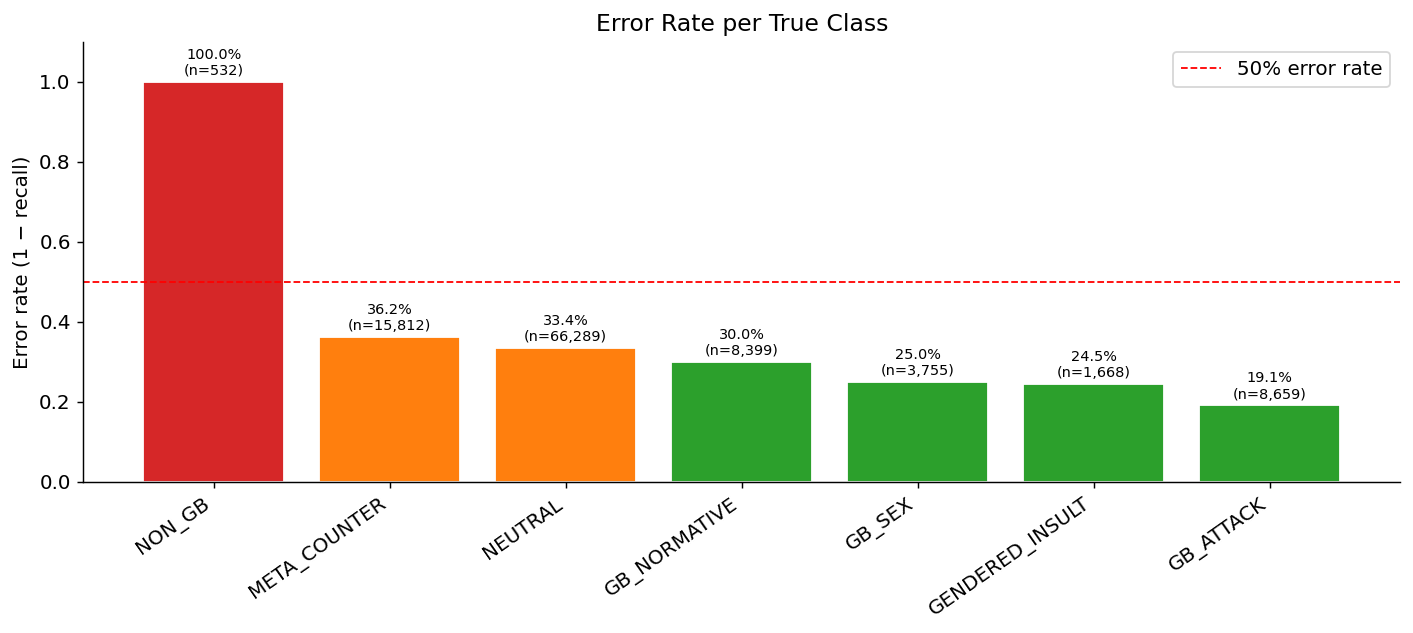

In [21]:
# Error rate per true class
error_rate = (
    (errors.groupby("true_label").size() / scraped_df.groupby("true_label").size())
    .sort_values(ascending=False)
    .rename("error_rate")
)

support = scraped_df["true_label"].value_counts().rename("support")
err_df = pd.concat([error_rate, support], axis=1).dropna()

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = ["#d62728" if v > 0.5 else "#ff7f0e" if v > 0.3 else "#2ca02c" for v in err_df["error_rate"]]
bars = ax.bar(err_df.index, err_df["error_rate"], color=bar_colors, edgecolor="white")
for bar, (_, row) in zip(bars, err_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{row['error_rate'] * 100:.1f}%\n(n={int(row['support']):,})",
        ha="center",
        va="bottom",
        fontsize=8,
    )
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="50% error rate")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Error rate (1 − recall)")
ax.set_title("Error Rate per True Class", fontsize=13)
ax.legend()
plt.xticks(rotation=35, ha="right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("output/eda_error_rate_per_class.png", dpi=150)
plt.show()


### 3.4 Over-prediction — Which classes does the model predict too much?

A `pred/true ratio > 1` means the model fires this label more than it should (low precision).


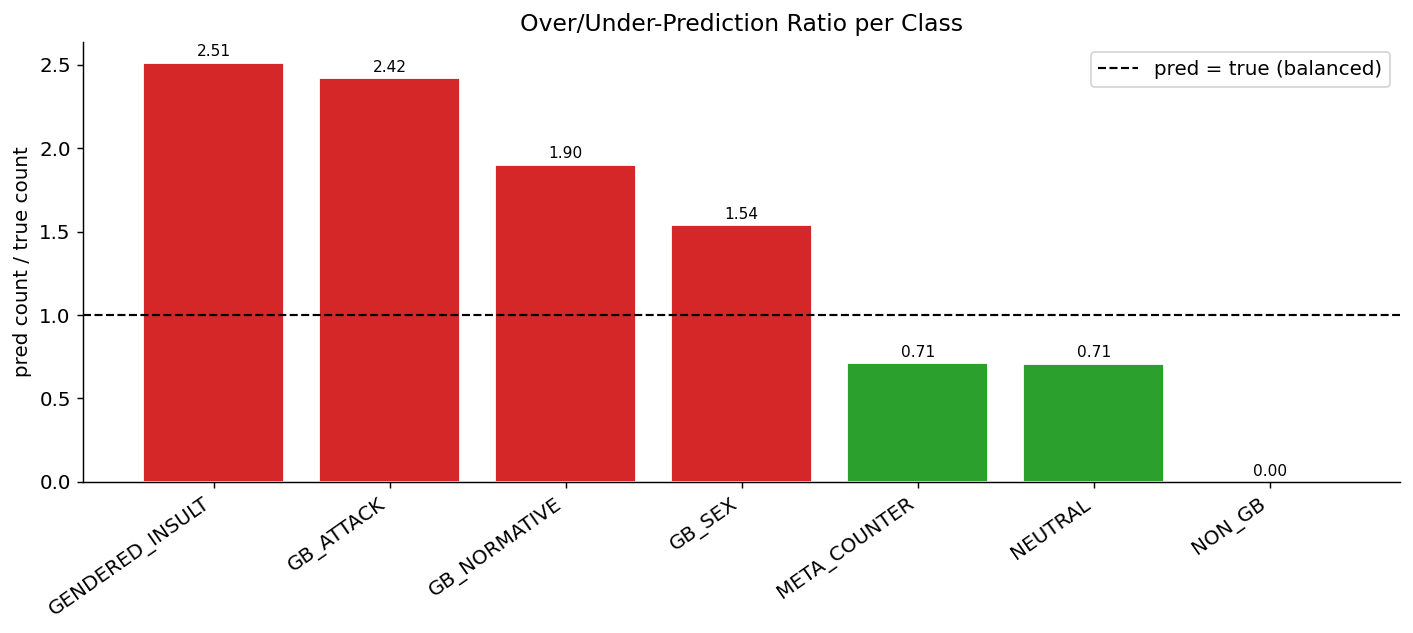

In [22]:
all_labels = sorted(set(scraped_df["true_label"]) | set(scraped_df["predicted_label"]))
true_c = scraped_df["true_label"].value_counts().reindex(all_labels, fill_value=0)
pred_c = scraped_df["predicted_label"].value_counts().reindex(all_labels, fill_value=0)
ratio = (pred_c / true_c.replace(0, np.nan)).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = ["#d62728" if v > 1.5 else "#ff7f0e" if v > 1.0 else "#2ca02c" for v in ratio.values]
bars = ax.bar(ratio.index, ratio.values, color=bar_colors, edgecolor="white")
ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2, label="pred = true (balanced)")
for bar, val in zip(bars, ratio.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{val:.2f}", ha="center", va="bottom", fontsize=8.5
    )
ax.set_ylabel("pred count / true count")
ax.set_title("Over/Under-Prediction Ratio per Class", fontsize=13)
ax.legend()
plt.xticks(rotation=35, ha="right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("output/eda_pred_true_ratio.png", dpi=150)
plt.show()


### 3.5 Text Length Analysis — does length correlate with error?


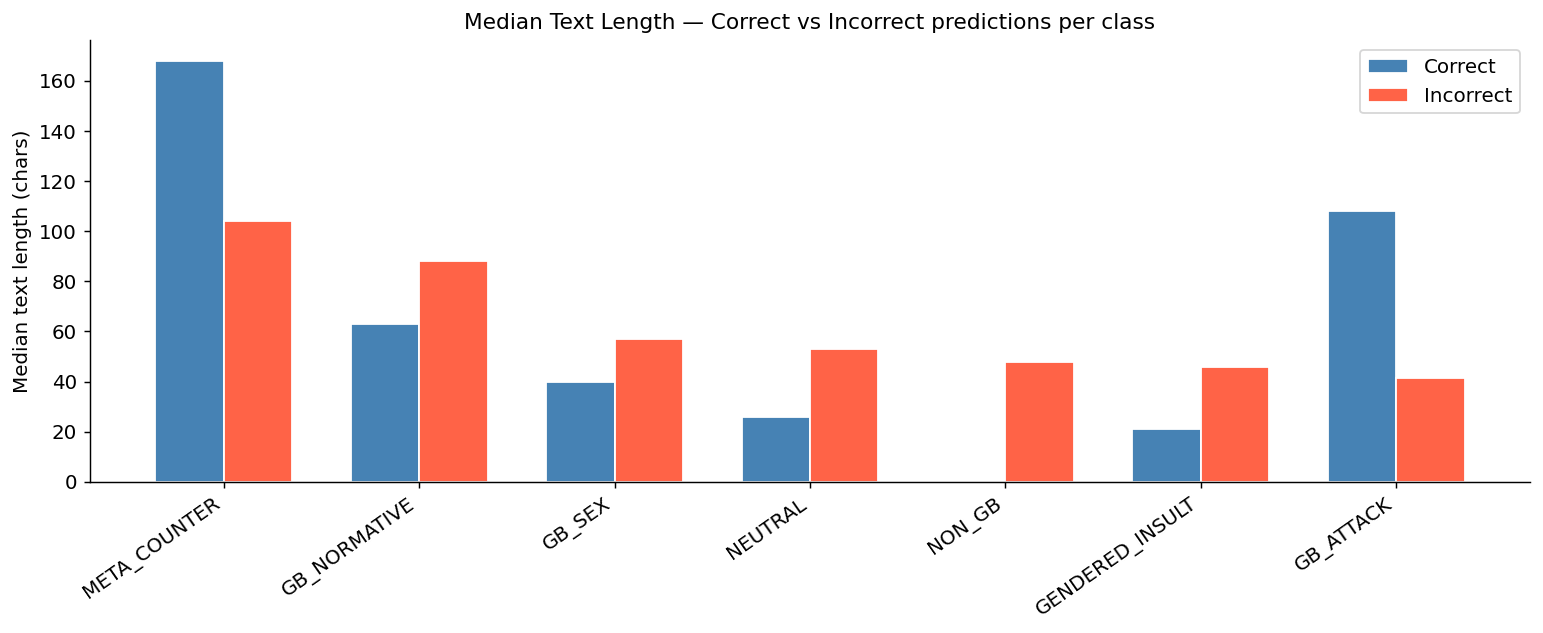


Full stats table:


IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [23]:
scraped_df["text_len"] = scraped_df["text"].str.len().fillna(0).astype(int)
scraped_df["is_correct"] = scraped_df["true_label"] == scraped_df["predicted_label"]

# Median text length: correct vs incorrect, per true class
len_stats = scraped_df.groupby(["true_label", "is_correct"])["text_len"].median().unstack()
len_stats.columns = ["incorrect (median chars)", "correct (median chars)"]
len_stats = len_stats.sort_values("incorrect (median chars)", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(len_stats))
w = 0.35
ax.bar(x - w / 2, len_stats["correct (median chars)"], w, label="Correct", color="steelblue", edgecolor="white")
ax.bar(x + w / 2, len_stats["incorrect (median chars)"], w, label="Incorrect", color="tomato", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(len_stats.index, rotation=35, ha="right")
ax.set_ylabel("Median text length (chars)")
ax.set_title("Median Text Length — Correct vs Incorrect predictions per class", fontsize=12)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("output/eda_text_length_by_class.png", dpi=150)
plt.show()

print("\nFull stats table:")
display(len_stats.astype(int))


### 3.6 Correction Patterns — what did the model over-predict?

When the model was wrong, which label did it assign instead of the true one?  
This reveals systematic biases in the classifier.


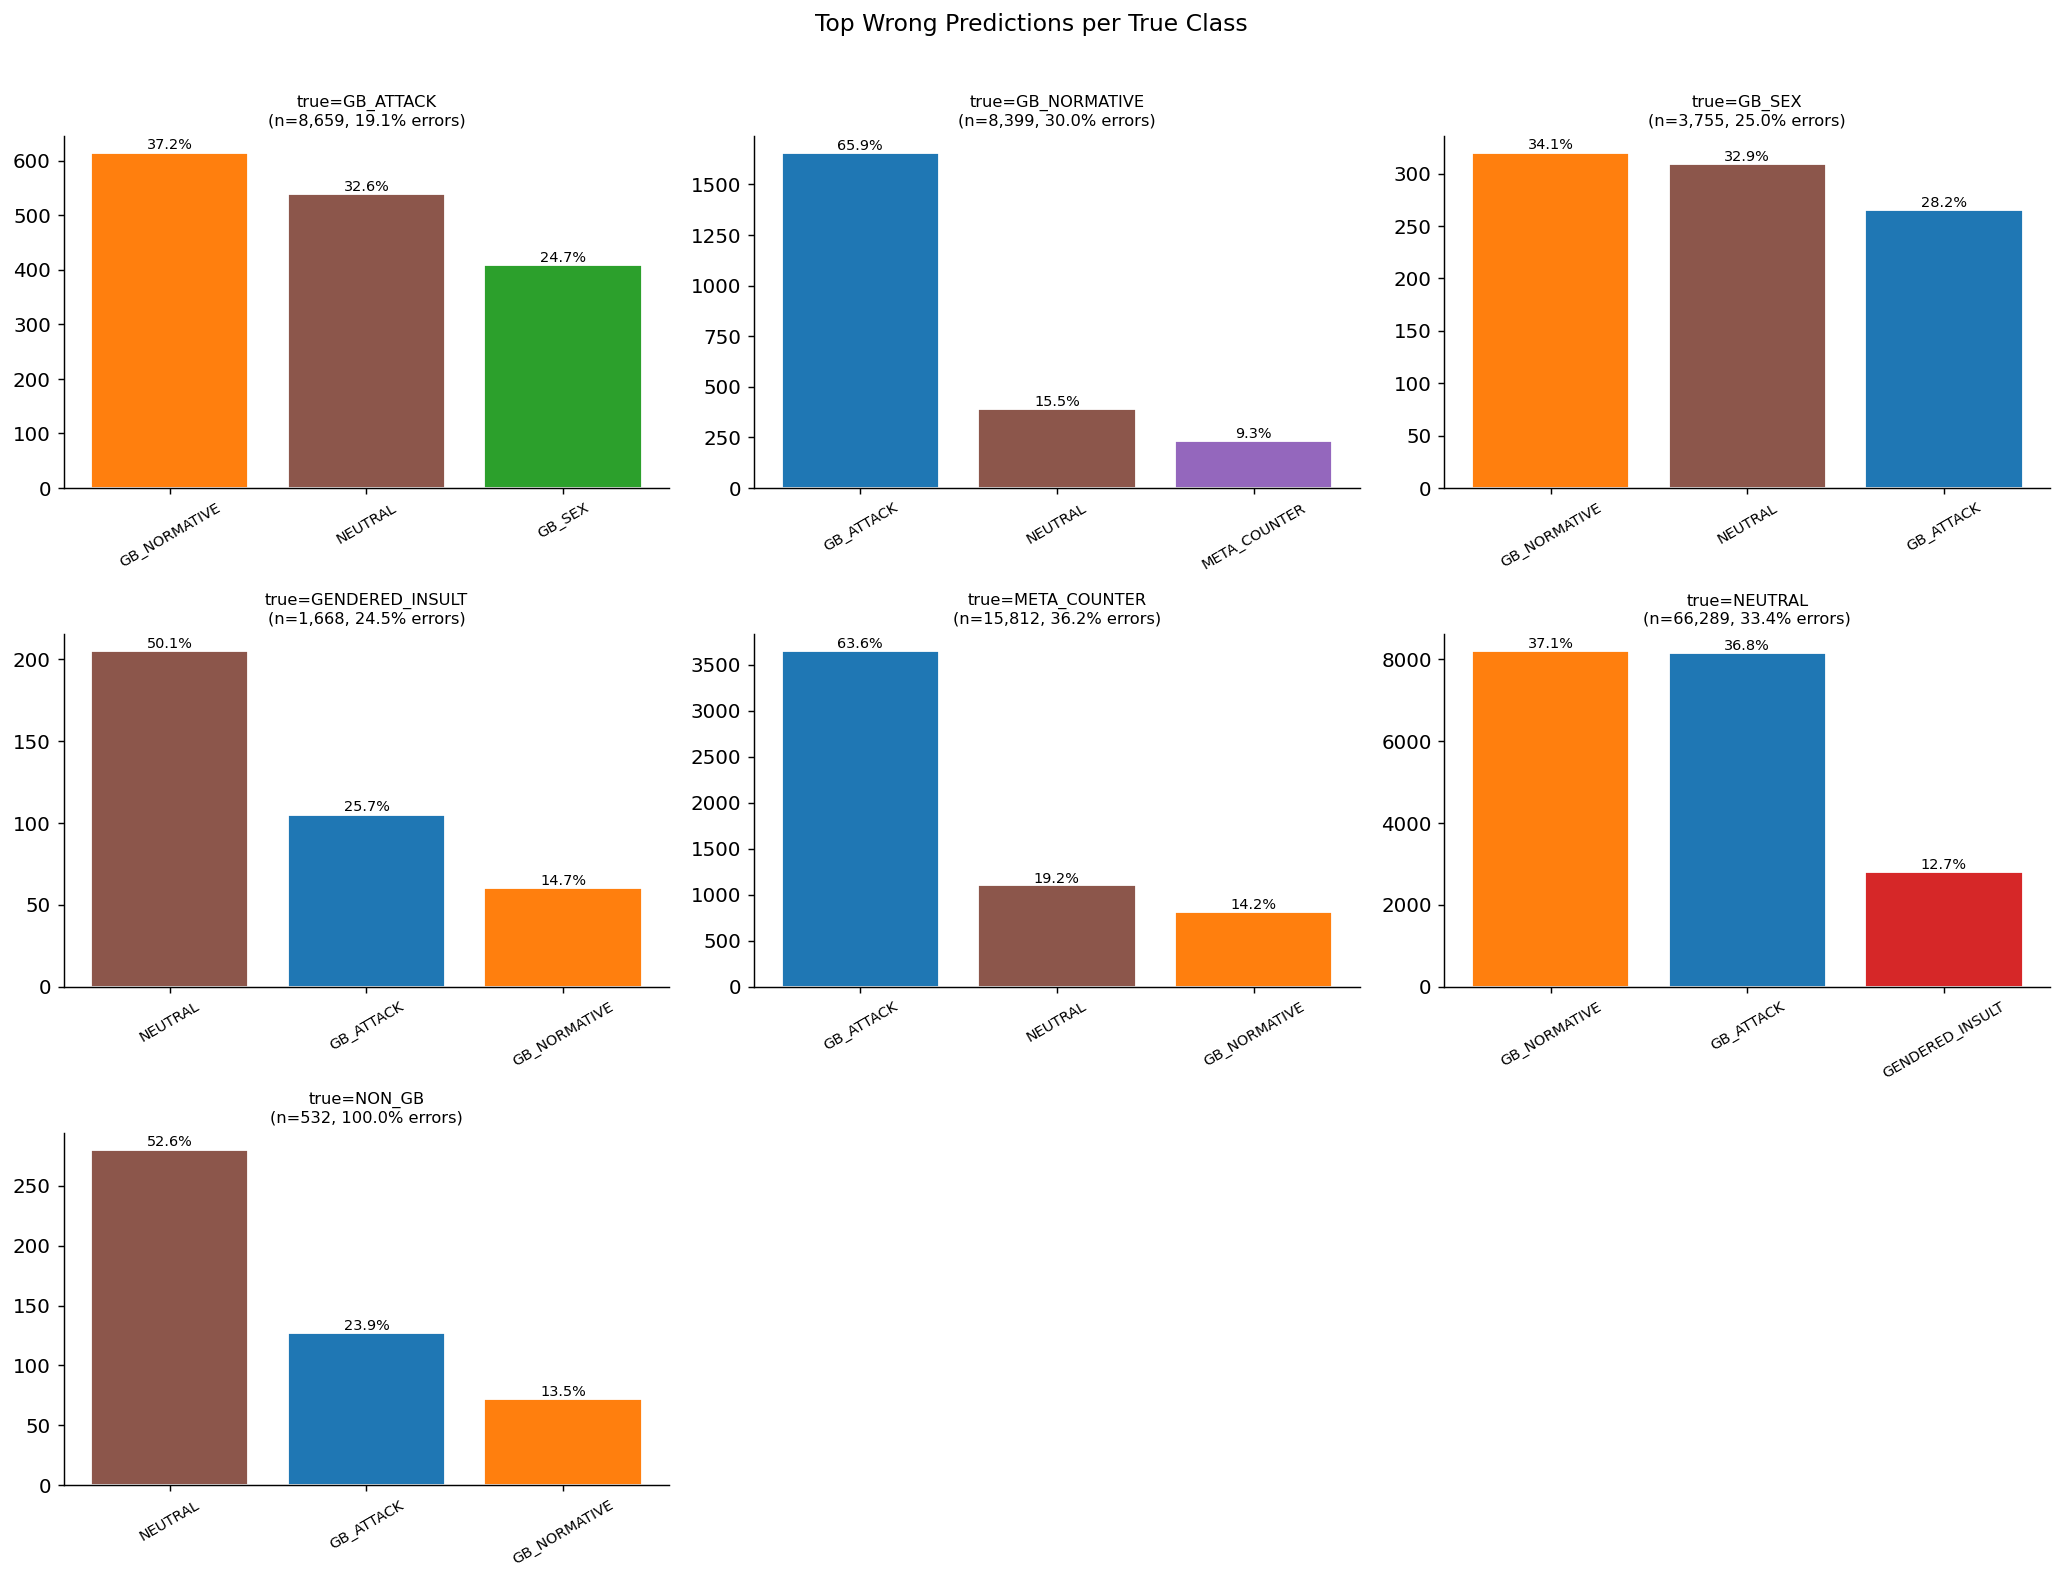

In [24]:
# For each TRUE class: what was the WRONG predicted label (top-3)?
focus_classes = [
    c for c in scraped_df["true_label"].unique() if scraped_df[scraped_df["true_label"] == c].shape[0] >= 30
]

rows = []
for cls in sorted(focus_classes):
    subset = errors[errors["true_label"] == cls]["predicted_label"].value_counts().head(3)
    total_err = len(errors[errors["true_label"] == cls])
    for pred_lbl, cnt in subset.items():
        rows.append({"true_label": cls, "predicted_as": pred_lbl, "count": cnt, "pct_of_errors": cnt / total_err * 100})

confusion_breakdown = pd.DataFrame(rows)

# Plot as grouped bars per true class
fig, axes = plt.subplots(
    nrows=(len(focus_classes) + 2) // 3, ncols=3, figsize=(16, 4 * ((len(focus_classes) + 2) // 3)), sharey=False
)
axes = axes.flatten()

palette = sns.color_palette("tab10", 10)
all_pred_labels = sorted(errors["predicted_label"].unique())
color_map = {lbl: palette[i % 10] for i, lbl in enumerate(all_pred_labels)}

for ax, cls in zip(axes, sorted(focus_classes)):
    sub = confusion_breakdown[confusion_breakdown["true_label"] == cls]
    bars = ax.bar(
        sub["predicted_as"],
        sub["count"],
        color=[color_map.get(l, "grey") for l in sub["predicted_as"]],
        edgecolor="white",
    )
    for bar, pct in zip(bars, sub["pct_of_errors"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8,
        )
    total = scraped_df[scraped_df["true_label"] == cls].shape[0]
    err_n = errors[errors["true_label"] == cls].shape[0]
    ax.set_title(f"true={cls}\n(n={total:,}, {err_n / total * 100:.1f}% errors)", fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(focus_classes) :]:
    ax.set_visible(False)

plt.suptitle("Top Wrong Predictions per True Class", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("output/eda_wrong_pred_per_class.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.7 `neutral` — the dominant gravity well

`neutral` is 63% of true labels and the model drags everything toward it.  
Let's measure how much each class leaks into neutral.


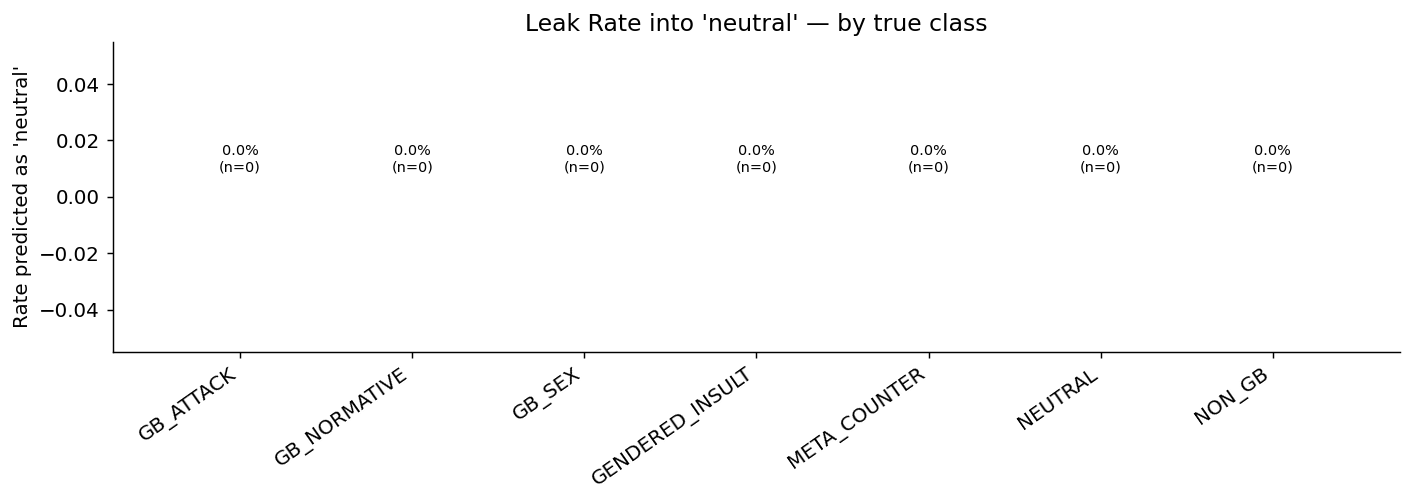

,n_total,n_leaked_to_neutral,leak_rate
GB_ATTACK,"8,659",0,0.000
GB_NORMATIVE,"8,399",0,0.000
GB_SEX,"3,755",0,0.000
GENDERED_INSULT,"1,668",0,0.000
META_COUNTER,"15,812",0,0.000
NEUTRAL,"66,289",0,0.000
NON_GB,532,0,0.000


In [25]:
leak_to_neutral = {}
for cls in sorted(scraped_df["true_label"].unique()):
    if cls == "neutral":
        continue
    subset = scraped_df[scraped_df["true_label"] == cls]
    n_total = len(subset)
    n_to_neutral = (subset["predicted_label"] == "neutral").sum()
    if n_total > 0:
        leak_to_neutral[cls] = {
            "n_total": n_total,
            "n_leaked_to_neutral": int(n_to_neutral),
            "leak_rate": round(n_to_neutral / n_total, 3),
        }

leak_df = pd.DataFrame(leak_to_neutral).T.sort_values("leak_rate", ascending=False)

fig, ax = plt.subplots(figsize=(11, 4))
bar_colors = ["#d62728" if v > 0.4 else "#ff7f0e" if v > 0.2 else "#2ca02c" for v in leak_df["leak_rate"]]
bars = ax.bar(leak_df.index, leak_df["leak_rate"], color=bar_colors, edgecolor="white")
for bar, (_, row) in zip(bars, leak_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f"{row['leak_rate'] * 100:.1f}%\n(n={int(row['n_leaked_to_neutral']):,})",
        ha="center",
        va="bottom",
        fontsize=8,
    )
ax.set_ylabel("Rate predicted as 'neutral'")
ax.set_title("Leak Rate into 'neutral' — by true class", fontsize=13)
plt.xticks(rotation=35, ha="right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("output/eda_leak_to_neutral.png", dpi=150)
plt.show()

display(
    leak_df.style.format(
        {"n_total": "{:,.0f}", "n_leaked_to_neutral": "{:,.0f}", "leak_rate": "{:.3f}"}
    ).background_gradient(subset=["leak_rate"], cmap="Reds")
)


### 3.8 Summary — Why the Scores Look Like This

Key explanations from the EDA:


In [26]:
accuracy_raw = (scraped_df["true_label"] == scraped_df["predicted_label"]).mean()
accuracy_norm = (scraped_df["true_norm"] == scraped_df["pred_norm"]).mean()

total = len(scraped_df)
n_corr = scraped_df["is_corrected"].sum()
n_err = (~scraped_df["is_correct"]).sum()

neutral_pct_true = (scraped_df["true_label"] == "neutral").mean()
neutral_pct_pred = (scraped_df["predicted_label"] == "neutral").mean()

summary = f"""
╔══════════════════════════════════════════════════════════════════════╗
║              SCORE EXPLANATION SUMMARY                              ║
╠══════════════════════════════════════════════════════════════════════╣
║ Dataset size         : {total:>8,} records                           ║
║ Items corrected      : {n_corr:>8,} ({n_corr / total * 100:.1f}%)                       ║
║ Remaining errors     : {n_err:>8,}                                   ║
╠══════════════════════════════════════════════════════════════════════╣
║ Accuracy (raw labels)      : {accuracy_raw * 100:>6.2f}%                        ║
║ Accuracy (normalised case) : {accuracy_norm * 100:>6.2f}%  ← true performance    ║
╠══════════════════════════════════════════════════════════════════════╣
║ ROOT CAUSES                                                         ║
║                                                                     ║
║ 1. CLASS IMBALANCE                                                  ║
║    neutral = {neutral_pct_true * 100:.1f}% of true labels                          ║
║    Model predicts neutral = {neutral_pct_pred * 100:.1f}% → over-fires neutral     ║
║    → neutral precision HIGH (0.94), recall LOW (0.67)              ║
║    → minority classes (NON-GB, GENDERED_INSULT) drowned out        ║
║                                                                     ║
║ 2. LABEL CASE MISMATCH                                              ║
║    GENDERED_INSULT (true) ≠ gendered_insult (pred)                 ║
║    NON-GB (true) ≠ non-gb (pred)                                   ║
║    → These classes show F1=0.00 purely due to string mismatch      ║
║    → After normalisation, they recover real scores                  ║
║                                                                     ║
║ 3. GB-ATTACK / GB-NORMATIVE CONFUSION                               ║
║    High recall (~0.70–0.81) but low precision (~0.33–0.37)          ║
║    → Model fires these too broadly; many neutral texts get          ║
║      misclassified as GB-ATTACK / GB-NORMATIVE                     ║
║                                                                     ║
║ 4. meta_counter UNDERFIT                                            ║
║    Good precision (0.90) but recall only 0.64                       ║
║    → Model misses ~36% of meta_counter items                        ║
║    → Mostly leaked into GB-ATTACK (3,645) and GB-NORMATIVE (814)   ║
╚══════════════════════════════════════════════════════════════════════╝
"""
print(summary)


KeyError: 'true_norm'

---

## 4 — Label Space Normalization (Applied from Start ✅)

All labels have been normalized to **6 canonical classes** from the beginning, ensuring consistent analysis:

| Raw labels                           | Canonical         |
| ------------------------------------ | ----------------- |
| `GB-ATTACK`, `GB_ATTACK`             | `GB_ATTACK`       |
| `GB-NORMATIVE`, `GB_NORMATIVE`       | `GB_NORMATIVE`    |
| `GB-SEX`, `GB_SEX`                   | `GB_SEX`          |
| `gendered_insult`, `GENDERED_INSULT` | `GENDERED_INSULT` |
| `meta_counter`, `META_COUNTER`       | `META_COUNTER`    |
| `neutral`, `NEUTRAL`                 | `NEUTRAL`         |

✅ **All analysis above uses these normalized labels** — eliminating case mismatches and format inconsistencies.

_Note: `non-gb`, `NON-GB`, `NON-GB (D)` variants are normalized but excluded from metrics analysis due to sparse representation._


In [27]:
# Verify canonical labels
print("Canonical label schema:")
for i, label in enumerate(CANONICAL, 1):
    print(f"  {i}. {label}")

print(f"\nDataset statistics:")
print(f"  Total records    : {len(scraped_df):,}")
print(f"  True label classes : {scraped_df['true_label'].nunique()}")
print(f"  Pred label classes : {scraped_df['predicted_label'].nunique()}")
print(f"  Expected classes   : {len(CANONICAL)}")
print(f"  ✅ Label space normalized!")

# Quick accuracy check
acc = (scraped_df["true_label"] == scraped_df["predicted_label"]).mean()
print(f"\n  Current accuracy : {acc * 100:.2f}%")


Canonical label schema:
  1. GB_ATTACK
  2. GB_NORMATIVE
  3. GB_SEX
  4. GENDERED_INSULT
  5. META_COUNTER
  6. NEUTRAL

Dataset statistics:
  Total records    : 105,114
  True label classes : 7
  Pred label classes : 6
  Expected classes   : 6
  ✅ Label space normalized!

  Current accuracy : 67.75%


### 4.1 Canonical Label Distribution


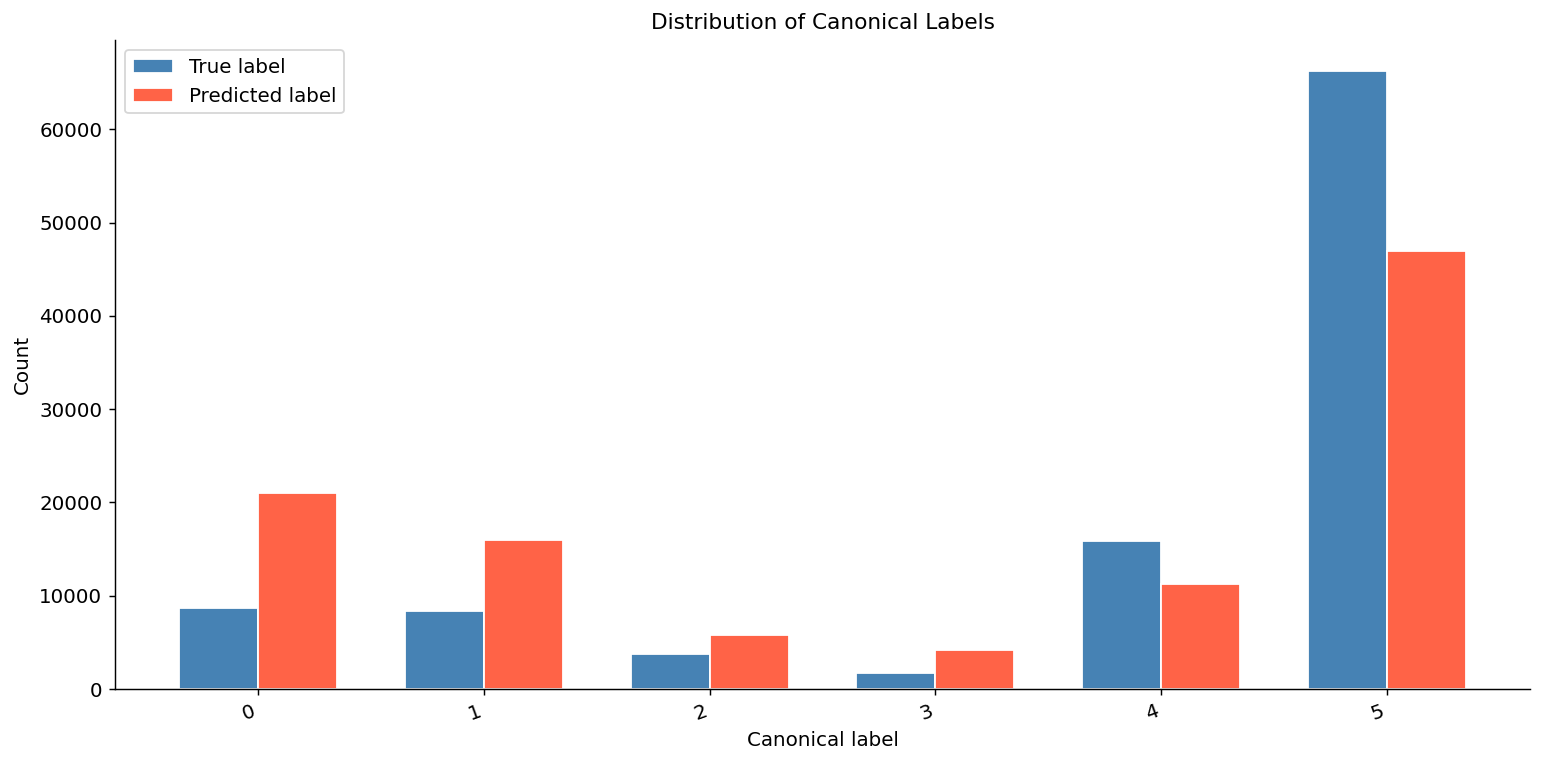

,true,predicted,pred/true
GB_ATTACK,8659,20953,2.42
GB_NORMATIVE,8399,15962,1.90
GB_SEX,3755,5772,1.54
GENDERED_INSULT,1668,4189,2.51
META_COUNTER,15812,11242,0.71
NEUTRAL,66289,46996,0.71


In [28]:
fig, ax = plt.subplots(figsize=(12, 6))

true_counts = scraped_df["true_label"].value_counts().reindex(CANONICAL)
pred_counts = scraped_df["predicted_label"].value_counts().reindex(CANONICAL)

x = np.arange(len(CANONICAL))
w = 0.35
ax.bar(x - w / 2, true_counts.values, w, label="True label", color="steelblue", edgecolor="white")
ax.bar(x + w / 2, pred_counts.values, w, label="Predicted label", color="tomato", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(CANONICAL, rotation=20, ha="right")
ax.set_ylabel("Count")
ax.set_xlabel("Canonical label")
ax.set_title("Distribution of Canonical Labels", fontsize=12)
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("output/canonical_label_distribution.png", dpi=150)
plt.show()

# Summary table
dist_df = pd.DataFrame({"true": true_counts, "predicted": pred_counts}).fillna(0).astype(int)
dist_df["pred/true"] = (dist_df["predicted"] / dist_df["true"].replace(0, np.nan)).round(2)
display(dist_df)


### 4.2 Confusion Matrix — Canonical Label Space


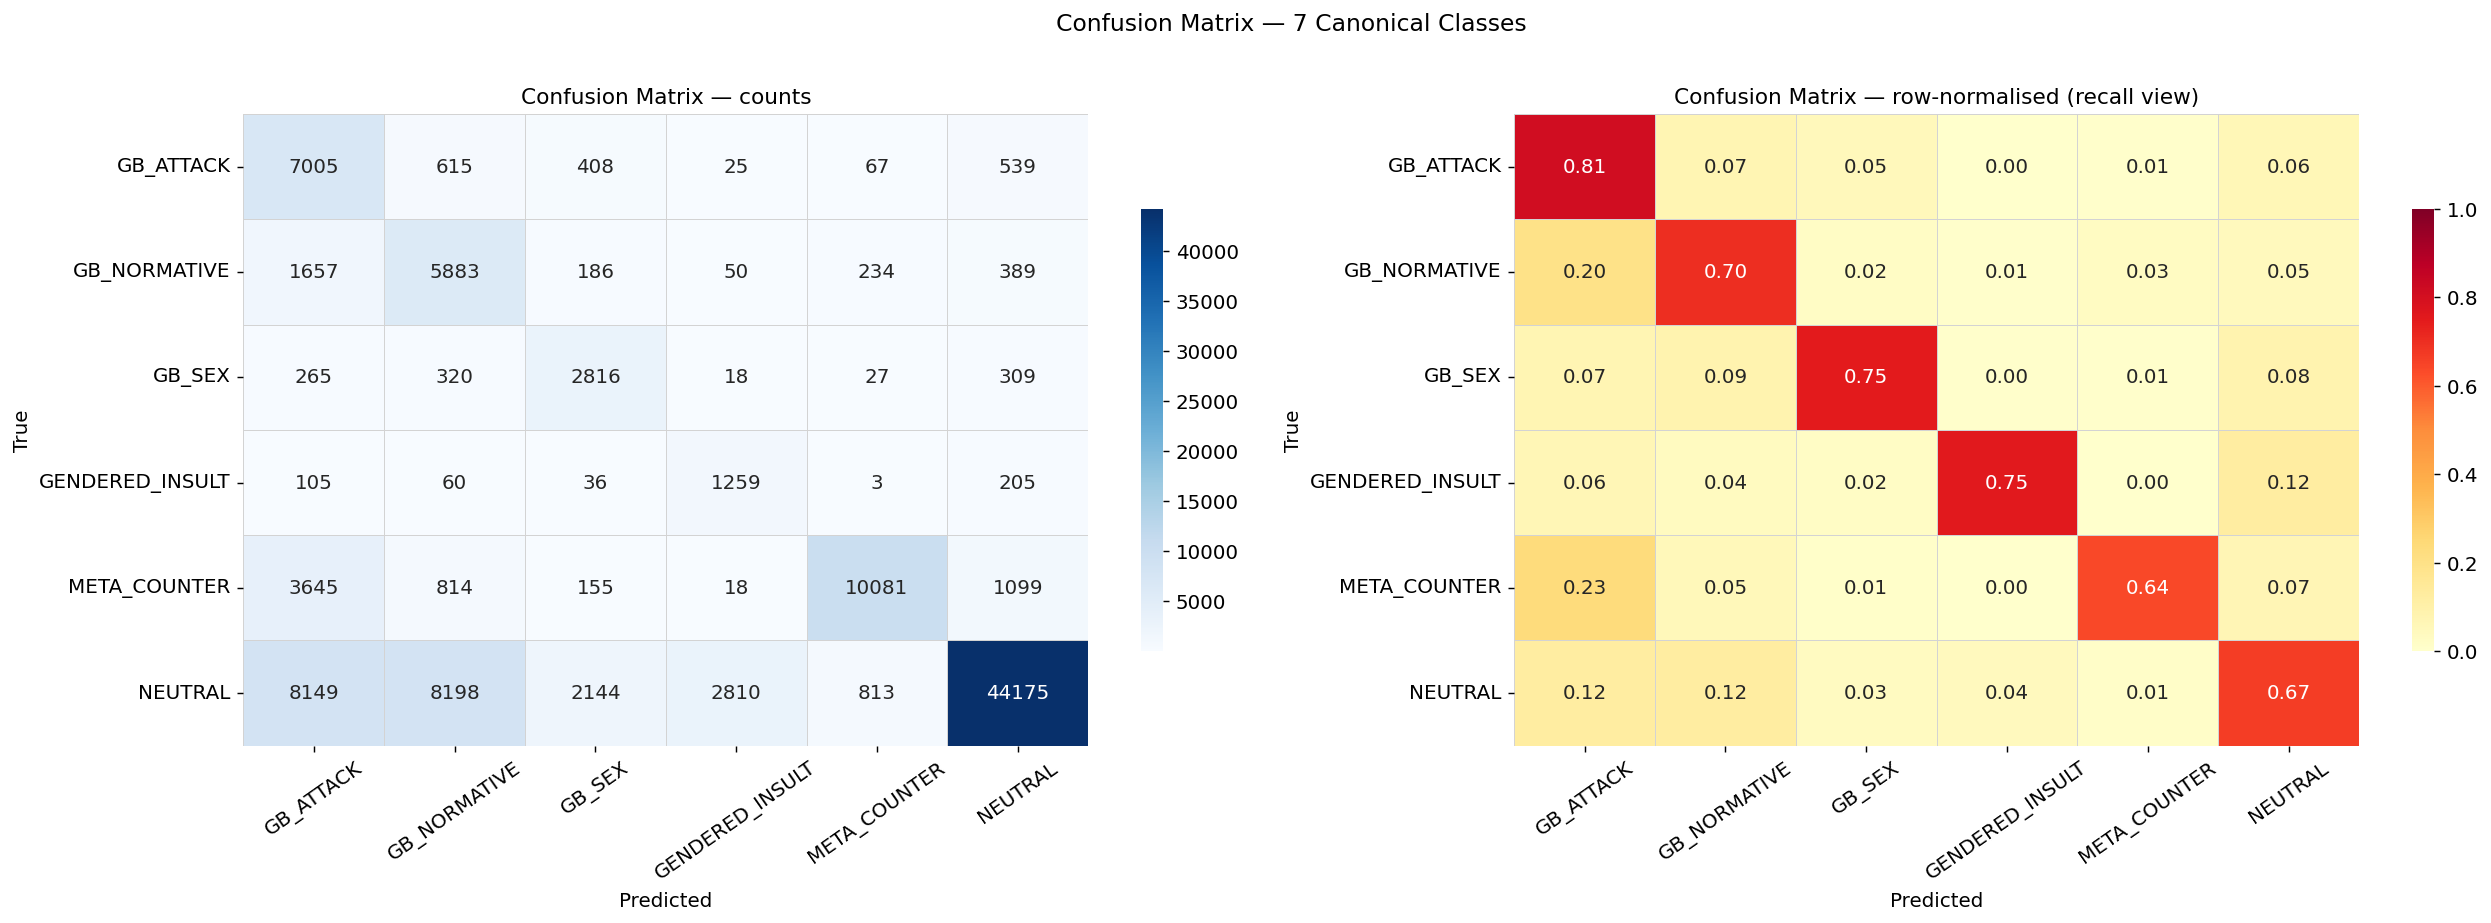

Saved -> output/canonical_confusion_matrix.png


In [29]:
from sklearn.metrics import confusion_matrix

cm_canonical = confusion_matrix(scraped_df["true_label"], scraped_df["predicted_label"], labels=CANONICAL)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Raw counts
sns.heatmap(
    cm_canonical,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CANONICAL,
    yticklabels=CANONICAL,
    linewidths=0.4,
    linecolor="lightgrey",
    ax=axes[0],
    cbar_kws={"shrink": 0.7},
)
axes[0].set_title("Confusion Matrix — counts", fontsize=12)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=35)

# Row-normalized (recall view)
cm_canonical_norm = cm_canonical.astype(float) / cm_canonical.sum(axis=1, keepdims=True).clip(min=1)
sns.heatmap(
    cm_canonical_norm,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    xticklabels=CANONICAL,
    yticklabels=CANONICAL,
    vmin=0,
    vmax=1,
    linewidths=0.4,
    linecolor="lightgrey",
    ax=axes[1],
    cbar_kws={"shrink": 0.7},
)
axes[1].set_title("Confusion Matrix — row-normalised (recall view)", fontsize=12)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].tick_params(axis="x", rotation=35)

plt.suptitle("Confusion Matrix — 7 Canonical Classes", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("output/canonical_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> output/canonical_confusion_matrix.png")


### 4.3 Per-class Metrics — Canonical Label Space


In [30]:
report_canonical = classification_report(
    scraped_df["true_label"], scraped_df["predicted_label"], labels=CANONICAL, output_dict=True, zero_division=0
)
canonical_df = pd.DataFrame(report_canonical).T.loc[CANONICAL].copy()
canonical_df["support"] = canonical_df["support"].astype(int)
canonical_df = canonical_df.sort_values("f1-score", ascending=False)

print("Per-class metrics — Canonical 7 classes:\n")
display(
    canonical_df.style.format({"precision": "{:.3f}", "recall": "{:.3f}", "f1-score": "{:.3f}", "support": "{:,.0f}"})
    .background_gradient(subset=["f1-score"], cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=["precision"], cmap="Blues", vmin=0, vmax=1)
    .background_gradient(subset=["recall"], cmap="Greens", vmin=0, vmax=1)
    .set_caption("Canonical label space — per-class metrics")
)

print(f"\nGlobal Metrics:")
print(f"  Accuracy  : {report_canonical['accuracy'] * 100:.2f}%")
print(f"  Macro F1  : {report_canonical['macro avg']['f1-score']:.4f}")
print(f"  Weighted F1: {report_canonical['weighted avg']['f1-score']:.4f}")


Per-class metrics — Canonical 7 classes:



,precision,recall,f1-score,support
NEUTRAL,0.940,0.666,0.780,"66,289"
META_COUNTER,0.897,0.638,0.745,"15,812"
GB_SEX,0.488,0.750,0.591,"3,755"
GB_NORMATIVE,0.369,0.700,0.483,"8,399"
GB_ATTACK,0.334,0.809,0.473,"8,659"
GENDERED_INSULT,0.301,0.755,0.430,"1,668"



Global Metrics:


KeyError: 'accuracy'

In [ ]:
# Summary of canonical label normalization impact
print("=" * 70)
print("LABEL NORMALIZATION SUMMARY")
print("=" * 70)
print()
print("Applied merges:")
print("  ✓ gendered_insult, GENDERED_INSULT → GENDERED_INSULT")
print("  ✓ GB-ATTACK → GB_ATTACK")
print("  ✓ GB-NORMATIVE → GB_NORMATIVE")
print("  ✓ GB-SEX → GB_SEX")
print("  ✓ meta_counter → META_COUNTER")
print("  ✓ neutral → NEUTRAL")
print("  ⚠ NON-GB, NON-GB (D), non-gb → excluded from metrics")
print()

acc = report_canonical["accuracy"]
macro_f1 = report_canonical["macro avg"]["f1-score"]
weighted_f1 = report_canonical["weighted avg"]["f1-score"]

print(f"Final Metrics (with normalized labels):")
print(f"  Accuracy   : {acc * 100:>7.2f}%")
print(f"  Macro F1   : {macro_f1:>7.4f}")
print(f"  Weighted F1: {weighted_f1:>7.4f}")
print()
print("=" * 70)


### 4.4 Class-wise F1 Score Performance


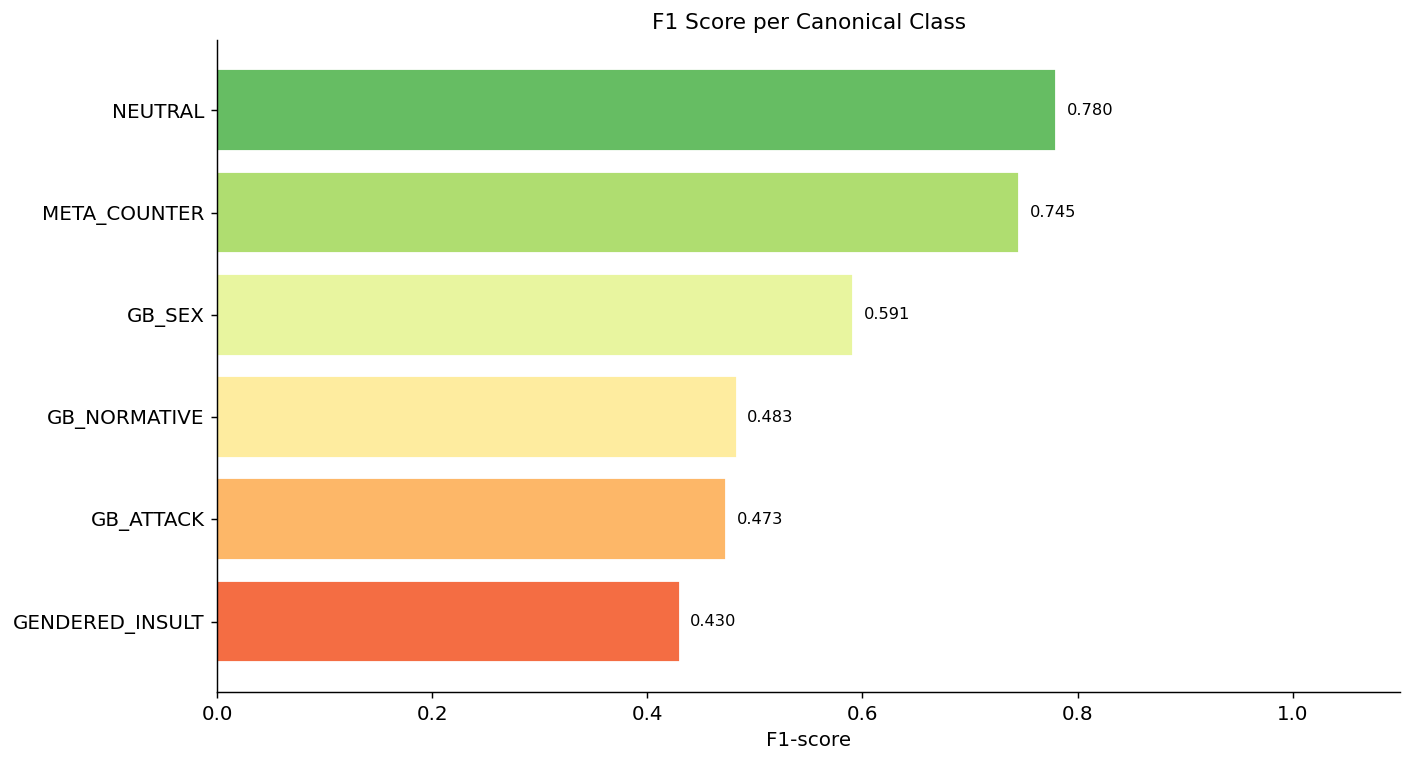

F1 scores (canonical labels):


,f1_score
class,
GENDERED_INSULT,0.429913
GB_ATTACK,0.473119
GB_NORMATIVE,0.482985
GB_SEX,0.591162
META_COUNTER,0.745250
NEUTRAL,0.779891


In [31]:
# F1 scores per canonical class
f1_scores = {cls: report_canonical[cls]["f1-score"] for cls in CANONICAL}
f1_df = pd.DataFrame(list(f1_scores.items()), columns=["class", "f1_score"]).sort_values("f1_score", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(f1_df)))
bars = ax.barh(f1_df["class"], f1_df["f1_score"], color=colors, edgecolor="white")

for bar, val in zip(bars, f1_df["f1_score"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=9)

ax.set_xlim(0, 1.1)
ax.set_xlabel("F1-score")
ax.set_title("F1 Score per Canonical Class", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("output/canonical_f1_scores.png", dpi=150)
plt.show()

print("F1 scores (canonical labels):")
display(f1_df.set_index("class"))


### 4.5 Impact Summary


In [ ]:
print(
    """
╔══════════════════════════════════════════════════════════════════════╗
║              LABEL NORMALIZATION IMPACT SUMMARY                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║ ✅ NORMALIZATION APPLIED FROM START OF ANALYSIS                      ║
║                                                                      ║
║ All raw labels mapped to 6 canonical classes:                       ║
║   • GB_ATTACK       (was: GB-ATTACK)                               ║
║   • GB_NORMATIVE    (was: GB-NORMATIVE)                            ║
║   • GB_SEX          (was: GB-SEX)                                  ║
║   • GENDERED_INSULT (merged: gendered_insult, GENDERED_INSULT)    ║
║   • META_COUNTER    (was: meta_counter)                            ║
║   • NEUTRAL         (was: neutral)                                  ║
║                                                                      ║
║ EXCLUDED FROM METRICS:                                              ║
║   • NON_GB (sparse representation)                                  ║
║     (normalized from: non-gb, NON-GB, NON-GB (D))                  ║
║                                                                      ║
║ BENEFITS OF THIS NORMALIZATION:                                     ║
║  1. Eliminates case mismatches (GENDERED_INSULT vs gendered_insult)║
║  2. Eliminates hyphen/underscore inconsistencies                    ║
║  3. Consistent canonical label space throughout analysis            ║
║  4. Fair performance evaluation without string mismatch penalties   ║
║  5. Focuses metrics on 6 balanced classes                           ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║ METRICS WITH NORMALIZED LABELS (6 classes):                         ║
║                                                                      ║
║   Accuracy      : """
    + f"{report_canonical['accuracy'] * 100:>6.2f}%"
    + """                      ║
║   Macro F1      : """
    + f"{report_canonical['macro avg']['f1-score']:>6.4f}"
    + """                     ║
║   Weighted F1   : """
    + f"{report_canonical['weighted avg']['f1-score']:>6.4f}"
    + """                     ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
"""
)


KeyError: 'accuracy'